In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



# Make Summary Plots for Mono Models 

### Plots to include:
* [Attentive listening task:](#Attentive_listening_task)
    * Model & human word correct with 1-talker 4-talker & stationary noise distractors 
    * Model & human confusions with 1-talker distractor
* [Target-distractor sex similarity:](#sex_similarity)
    * Model & human word correct with same/different flags (rows for model & human)
    * add confusions as separate panel, same legend & arrangement 
* [Harmonic vs inharmonic speech from model](#harmonicity)

* [Stream correlations for several architectures on same plot](#corrs)

In [2]:
plot_out_dir = Path('/om2/user/imgriff/projects/Auditory-Attention/results_figs/mono_model_plots/')

In [3]:
plot_out_dir.mkdir(exist_ok=True, parents=True)

### Get TIMIT pandas for metadata

In [4]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now

In [5]:
# df_paths

In [6]:
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)

In [7]:
# pd.concat(meta_df, axis=0)

### Get experimental results csv

In [8]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))

In [9]:
results_files

[PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4926170_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4928442_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934342_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934809_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4941864_batch_results.csv')]

In [10]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)


In [11]:
# Get data from each batch file 
dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)
    df = df.rename(index={ix:f'p{ix}' for ix in range(len(df))})

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth = truth.dropna(axis='columns')
    truth = pd.melt(truth.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'stim_path',
                    ignore_index=False)

    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    responses = responses.dropna(axis='columns')

    responses = pd.melt(responses.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'guessed_word',
                    ignore_index=False)

    results = responses.merge(truth, on=['index', 'participant'])
    results['participant'] = results['participant'] + f'_{ix}' 

    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_path'].map(file_name_to_labels))

    ## Get distractor information from dfs 
    for stim_subset in results.stim_subset.unique():
        # get ixs for samples with this dataset
        result_ixs = np.where(results.stim_subset == stim_subset)[0]
        # get matching metadata
        meta_subset = meta_df[meta_df.stim_subset == stim_subset]
        results.loc[result_ixs, 'distractor_words'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_words']].values
        results.loc[result_ixs, 'distractor_sex'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_sex']].values
    dfs.append(results)
results = pd.concat(dfs)
print(results.shape)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

(9100, 12)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

#### Process results csv to plotting format

In [12]:
len(results.participant.unique())

50

In [13]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [14]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [15]:
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()


In [16]:
len(catch_trial_particiapnt_performance) # catch trial performance for each participant 

50

In [17]:
# filter out bad performers on catch trials  
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index

In [18]:
good_results = results[results.participant.isin(good_participants)]

## Get model results all subsets

In [19]:
parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/')
timit_results = list(parent_path.rglob("*.csv"))

In [20]:
timit_results

[PosixPath('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/metrics.csv')]

In [21]:
model_results = pd.read_csv(timit_results[0])

In [22]:
model_results.shape

(41492, 3)

In [23]:
model_results.head()

,ACC/test_fg_acc,pred_word_ix,step
0,1.0,552.0,0
1,0.0,392.0,1
2,0.0,689.0,2
3,1.0,659.0,3
4,0.0,90.0,4


In [24]:
model_results = model_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in model_results.index})
model_results['pred_word_ix'] = model_results['pred_word_ix'].astype('int') 

In [25]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_attn_stim_for_model_all_targets_metadata_only.pdpkl')

In [26]:
model_meta_df = model_meta_df.loc[:,~model_meta_df.columns.str.contains('signal')]

In [27]:
model_results['guessed_word'] = model_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
model_results['true_word'] = model_meta_df.loc[model_results.orig_df_ix, ['word']].values
model_results['distractor_words'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_words']].values
model_results['distractor_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_sex']].values
model_results['snr'] = model_meta_df.loc[model_results.orig_df_ix, ['snrs']].values.astype('str')
model_results['distractor_condition'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
model_results['target_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['speaker_sex']].values


In [28]:
model_results['confusions'] = model_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [29]:
model_results['subject'] = 'model'
good_results['subject'] = 'human'

/tmp/ipykernel_1277029/3491488986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_results['subject'] = 'human'


In [30]:
all_results = pd.concat([good_results, model_results])

<a id='Attentive_listening_task'></a>
# Attentive listening task plots

In [31]:
# set ssn to noise for plots 
all_results = all_results.replace('ssn', 'noise', regex=True)

In [32]:
turk_results = all_results[all_results['subject'] == 'human']

turk_summary_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



turk_conf_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())




In [33]:
turk_summary_df.head()

,snr,participant,distractor_condition,mean
0,-3,p12_1,1,0.8
1,-3,p12_1,2,0.3
2,-3,p12_1,4,0.3
3,-3,p12_1,noise,0.4
4,-3,p18_1,1,0.5


## Summary figure for grant 

In [34]:
## Process for confusions and sex comparisons

## map male/female to same/different 


def remap_sex_strs(target_sex, distractors):
    if isinstance(distractors,float):
        return distractors
    if distractors == 'noise':
        return distractors 
    same_diff = ''.join(['s' if char == target_sex else 'd' for char in distractors])
    return same_diff

all_results['distractor_type'] = all_results[['target_sex',
                                              'distractor_sex']].apply(lambda x: remap_sex_strs(x.target_sex, x.distractor_sex),
                                                    axis=1)


In [35]:
## Make distractor hue colors 

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

from itertools import groupby


distractor_hue_order = ['s', 'd', 'ss', 'sd', 'dd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']

grouped_distractors = [list(set(items)) for length, items in groupby(distractor_hue_order, key=len)]
grouped_distractors = [sorted(elems) for elems in grouped_distractors]

distractor_palette = {}
print(grouped_distractors)

color_palettes = [sns.diverging_palette(220, 20, center="dark", n=2, as_cmap=False),
                sns.diverging_palette(145, 300, center="dark", s=60, n=3, as_cmap=False),
                sns.color_palette("coolwarm", n_colors=5, as_cmap=False)]


for g_ix, group in enumerate(grouped_distractors):
    n_in_group = len(group)
    for d_ix, dist in enumerate(group):
        distractor_palette[dist] = color_palettes[g_ix][d_ix]


distractor_palette['ssdd'] = distractor_palette['sd']

# skip 2 distractor condition
sex_distractor_palette = {k:v for k,v in distractor_palette.items() if len(k) !=2}
sex_distractor_hue_order = ['s', 'd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']


[['d', 's'], ['dd', 'sd', 'ss'], ['dddd', 'sddd', 'ssdd', 'sssd', 'ssss']]


In [36]:
## Get stats for sex similarity plots:

turk_results = all_results[all_results['subject'] == 'human']

turk_by_sex_accuracy_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())

turk_by_sex_accuracy_df.rename(columns={'mean':'accuracy'}, inplace=True)
turk_by_sex_confusion_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())
turk_by_sex_confusion_df.rename(columns={'mean':'confusions'}, inplace=True)




# turk_summary_df = (turk_results.groupby(["snr", 'participant',
#                                          "distractor_condition", "distractor_sex", 'target_sex'])
#                      .accuracy
#                      .agg(["mean"])
#                      .reset_index())

turk_by_sex_accuracy_df.head()

,snr,participant,distractor_condition,distractor_type,accuracy
0,-3,p12_1,1,d,1.0
1,-3,p12_1,1,s,0.6
2,-3,p12_1,2,dd,0.0
3,-3,p12_1,2,ds,0.0
4,-3,p12_1,2,sd,1.0


In [37]:
sex_acc = pd.merge(turk_by_sex_accuracy_df, all_results[all_results.subject=='model'], 
        on=['snr', 'participant', 'distractor_condition', 'distractor_type',
       'accuracy'],

        how='outer')
sex_acc['subject'][~sex_acc.participant.isna()] = 'human'

/tmp/ipykernel_1277029/2228803891.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sex_acc['subject'][~sex_acc.participant.isna()] = 'human'


In [38]:
sex_name_update = {'s': "Same", 'd':'Different'}
sex_acc['distractor_type'] = sex_acc['distractor_type'].replace(sex_name_update)
turk_by_sex_confusion_df['distractor_type'] = turk_by_sex_confusion_df['distractor_type'].replace(sex_name_update)
sex_distractor_palette = {(sex_name_update[k] if k in sex_name_update.keys() else k):v 
                          for k,v in sex_distractor_palette.items()}

In [39]:
dist_name_update = {'1': "1 talker", '4':'4 talker', 'noise':'noise'}
turk_summary_df['distractor_condition'] = turk_summary_df['distractor_condition'].replace(dist_name_update)
all_results['distractor_condition'] = all_results['distractor_condition'].replace(dist_name_update)

In [45]:
turk_summary_df.head()

,snr,participant,distractor_condition,mean
0,-3,p12_1,1 talker,0.8
1,-3,p12_1,2,0.3
2,-3,p12_1,4 talker,0.3
3,-3,p12_1,noise,0.4
4,-3,p18_1,1 talker,0.5


<a id='harmonicity'></a>

# Harmonic v inharmonic 

### Get results from jitter_fn rendered harmonic speech 

In [49]:

parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_harmonic_speech_jitter_render_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
harmonic_file = parent_path.rglob("*.csv")
harmonic_results = pd.read_csv(next(harmonic_file))

# For clean, use version_1 for Harmonic speech generated with shift f0 function
# For clean, use version_2 for Harmonic speech generated with STRAIGHT resynth via - StraightDummySynth.m

clean_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_harmonic_speech_jitter_render_attn_task_clean_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
clean_harmonic_file = clean_path.rglob("*.csv")
clean_harmonic_results = pd.read_csv(next(clean_harmonic_file))

harmonic_results = harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
harmonic_results['pred_word_ix'] = harmonic_results['pred_word_ix'].astype('int') 

clean_harmonic_results = clean_harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in clean_harmonic_results.index})
clean_harmonic_results['pred_word_ix'] = clean_harmonic_results['pred_word_ix'].astype('int') 


### Get metadata for harmonic stimuli

In [50]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/harmonic_timit/')

harmonic_meta_data = pd.read_pickle(out_path / 'all_targets_harmonic_single_distractor_0dB_SNR_jitter_fn_render.pdpkl')

In [51]:
harmonic_results['guessed_word'] = harmonic_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
harmonic_results['true_word'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['word']].values
harmonic_results['distractor_words'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_words']].values
harmonic_results['distractor_sex'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_sex']].values
harmonic_results['snr'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['snrs']].values.astype('str')
harmonic_results['distractor_condition'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
harmonic_results['target_sex'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['speaker_sex']].values

harmonic_results['distractor_condition'] = 'Harmonic'

clean_harmonic_results['guessed_word'] = clean_harmonic_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
clean_harmonic_results['true_word'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['word']].values
clean_harmonic_results['target_sex'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['speaker_sex']].values

clean_harmonic_results['distractor_condition'] = 'Harmonic Clean'


### Get Inharmonic Results

In [52]:
parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_inharmonic_speech_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/')
inharm_file = parent_path.rglob("*.csv")
inharm_results = pd.read_csv(next(inharm_file))

clean_inharm_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/')
clean_inharm_path = clean_inharm_path / 'TIMIT_inharmonic_speech_attn_task_clean_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_0/'

clean_inharm_path = clean_inharm_path.rglob('*.csv')
clean_inharm_results = pd.read_csv(next(clean_inharm_path))

clean_inharm_results = clean_inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
clean_inharm_results['pred_word_ix'] = clean_inharm_results['pred_word_ix'].astype('int') 

inharm_results = inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
inharm_results['pred_word_ix'] = inharm_results['pred_word_ix'].astype('int') 

In [53]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/inharmonic_timit/')

inharm_meta_data = pd.read_pickle(out_path / 'all_targets_inharmonic_single_distractor_0dB_SNR.pdpkl')

In [54]:
clean_inharm_results['guessed_word'] = clean_inharm_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
clean_inharm_results['true_word'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['word']].values
clean_inharm_results['target_sex'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['speaker_sex']].values



In [55]:
clean_inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter) Clean'

In [56]:
inharm_results['guessed_word'] = inharm_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
inharm_results['true_word'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['word']].values
inharm_results['distractor_words'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_words']].values
inharm_results['distractor_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_sex']].values
inharm_results['snr'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['snrs']].values.astype('str')
inharm_results['distractor_condition'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
inharm_results['target_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['speaker_sex']].values



In [57]:
inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter)'

In [58]:
## combine_dfs 

harmonicity_results = pd.concat([harmonic_results,
                         clean_harmonic_results,
                         inharm_results,
                         clean_inharm_results], ignore_index=True)

get_confusion = lambda row: int(row.guessed_word in row.distractor_words) if not isinstance(row.distractor_words, float) else row.distractor_words

harmonicity_results['confusion'] = harmonicity_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)


In [59]:
spch_rslts = pd.melt(harmonicity_results, id_vars=['distractor_condition'],

        value_vars=['accuracy', 'confusion'],
        value_name = 'hits',
        var_name = 'attended_stream')

spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"

spch_rslts['attended_stream'][spch_rslts['distractor_condition'].str.contains('Clean')] = "Single sentence"
spch_rslts['distractor_condition'] = spch_rslts['distractor_condition'].apply(lambda x: x.replace(' Clean', ''))


/tmp/ipykernel_1277029/2643542157.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
/tmp/ipykernel_1277029/2643542157.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"
/tmp/ipykernel_1277029/2643542157.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-cop

In [64]:
spch_rslts.replace("Inharmonic \n (0.3 jitter)", "Inharmonic", inplace=True)

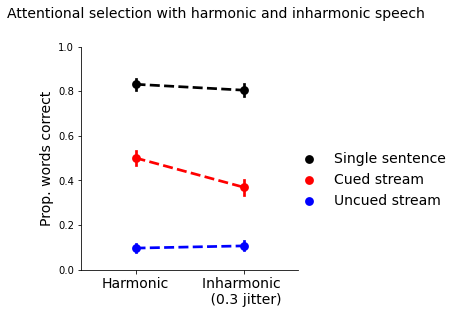

In [454]:
order = ['Harmonic', 'Inharmonic']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    linestyles='--',
    height=4, ratio=.75,
)


g.set_axis_labels("", "Prop. words correct", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
# g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Attentional selection with harmonic and inharmonic speech', y = 1.1,size=fontsize)
# g.fig.tight_layout()
# plt.savefig(plot_out_dir / 'harmonicity_plot.pdf',  bbox_inches='tight')
# plt.savefig(plot_out_dir / 'harmonicity_plot.svg',  format="svg", bbox_inches='tight')

## Put on one figure 

In [106]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1 talker', '4 talker', 'noise']
sex_distractor_hue_order = ['Same', 'Different']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'

n_participants = len(turk_summary_df.participant.unique())


fig, axs = plt.subplots(4,2, figsize=(6,13), sharey=False, sharex=False)
axs = axs.ravel()

# attn 
g = sns.pointplot( data=turk_summary_df, x = 'snr', y = 'mean', order=snr_order,
            hue ='distractor_condition',  error='sem', 
            hue_order=hue_order, palette=distractor_palette, 
            ax=axs[0])

g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition', linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[1])

# same diff sex acc
# 1 distractor 
g2 = sns.pointplot( data=sex_acc[(sex_acc.subject=='human') & (sex_acc.distractor_condition=='1')],
              x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type',  error='sem', 
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette, 
            ax=axs[2])

g3 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1')], 
                   x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type', linestyles='--',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[3])


# same diff sex confs 
g4 = sns.pointplot( data=turk_by_sex_confusion_df[turk_by_sex_confusion_df['distractor_condition']=='1'],
              x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type',  error='sem', 
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette, 
            ax=axs[4])

g5 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1')], 
                   x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type', linestyles='--',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[5])

## Harmonicity Results

g6 = sns.pointplot( data=spch_rslts, 
             x = 'distractor_condition', y = 'hits',
            order=['Harmonic', 'Inharmonic'],
            hue ='attended_stream', linestyles='--',
            hue_order=['Single sentence', 'Cued stream', 'Uncued stream'],
            palette=['k', 'r', 'b'], markers='.',
            errorbar=('ci', 95), n_boot=1000, seed=1,
            errwidth=3,
            ax=axs[7])


axs[6].axis('off')

# attn word rec
axs[0].set_title(f"Human Performance\nN={n_participants}",fontsize=fontsize, pad = -20)
axs[1].set_title("Model Performance", fontsize=fontsize, pad = 20)

axs[0].set_ylabel("Prop. word correct", fontsize=fontsize,)# weight='bold')
axs[1].set_ylabel("", fontsize=fontsize)

# same/diff sex word rec

axs[2].set_title("Human 1-distractor", fontsize=fontsize, pad = 20)
axs[3].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)

axs[2].set_ylabel("Prop. word correct", fontsize=fontsize,)# weight='bold')
axs[3].set_ylabel("", fontsize=fontsize)

# same/diff sex confusions
axs[4].set_title("Human 1-distractor", fontsize=fontsize, pad = 20)
axs[5].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)

axs[4].set_ylabel("Prop. confusions", fontsize=fontsize,)# weight='bold')
axs[5].set_ylabel("", fontsize=fontsize)

axs[6].set_ylabel("Prop. word correct", fontsize=fontsize,)# weight='bold')

axs[7].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)
axs[7].set_ylabel("", fontsize=fontsize)
axs[7].set_xlabel("", fontsize=fontsize)

# set common x label
np.vectorize(lambda x: x.set_xlabel("dB SNR", fontsize=fontsize-4))(axs[:6])

# set x ticks 
g.set_xticklabels(snr_order, size=fontsize)
g1.set_xticklabels(snr_order, size=fontsize)
g2.set_xticklabels(snr_order, size=fontsize)
g3.set_xticklabels(snr_order, size=fontsize)
g4.set_xticklabels(snr_order, size=fontsize)
g5.set_xticklabels(snr_order, size=fontsize)

g6.set_xticklabels(['Harmonic', 'Inharmonic'], size=fontsize-4)

sns.despine()


# axs[0].get_legend().remove()
axs[0].get_legend().remove()
axs[2].get_legend().remove()
axs[4].get_legend().remove()
axs[5].get_legend().remove()

axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)
axs[2].set_ylim(0,1)
axs[3].set_ylim(0,1)
axs[4].set_ylim(0,1)
axs[5].set_ylim(0,1)
axs[7].set_ylim(0,1)

for ax in axs:
    for label in ax.get_yticklabels():
#     label.set_fontproperties(font_prop)
        label.set_fontsize(fontsize-2)


plt.subplots_adjust(wspace=0.3,
                    hspace=0.7)


sns.move_legend(g1, title='distractor\ncondition', 
                loc="best", bbox_to_anchor=(1.8, 1.1),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)

sns.move_legend(g3, title='distractor\nsex', 
                loc="best", bbox_to_anchor=(1.85, 0.3),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)

sns.move_legend(g6, title='', 
                loc="best", bbox_to_anchor=(0.9, 0.9),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)


# plt.ylim(0,1)
# fig.subplots_adjust(top=0.7) # adjust the Figure in rp
# fig.suptitle('Attentive listening task', size=fontsize)
# plt.tight_layout()
plt.savefig(plot_out_dir / 'mono_summary_plot.pdf', bbox_inches='tight')
# plt.savefig(plot_out_dir / 'attentive_listening_task.svg', bbox_inches='tight',  format="svg")

In [103]:
plot_out_dir

PosixPath('/om2/user/imgriff/projects/Auditory-Attention/results_figs/mono_model_plots')

<a id='corrs'></a>

# Target-mixture correlations by Layer

In [51]:
corr_paths = list(Path('../').glob('*corrs*.pkl'))
skip = 'attn_cue_jsin_multi_distractor_w_audioset_full_SNR_-20_to_20_bs_64_lr_1e-4_corrs'
corr_paths = [path for path in corr_paths if ('noise' not in path.stem) and (path.stem != skip)]

In [52]:
model_dfs = []

for path in corr_paths:
    with open(path, 'rb') as f:
        acts = pickle.load(f)
    for layer in acts['fg_corr_results'].keys():
        df = pd.DataFrame.from_dict({'fg_corrs':acts['fg_corr_results'][layer],
                                 'bg_corrs':acts['bg_corr_results'][layer],
                                 'layer': [layer] * len(acts['fg_corr_results'][layer])})
    #                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
        df['model'] = path.stem
        model_dfs.append(df)

model_df = pd.concat(model_dfs)


In [53]:
model_df['with_noise'] = model_df.model.str.contains('audioset')

In [54]:

results = pd.melt(model_df, id_vars =['layer','with_noise', 'model'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")

In [55]:
results = (results.groupby(["layer", 'Stream', 'with_noise', 'model'])["Pearson's r"]
                     .agg(["mean"])
                     .reset_index())
results = results.rename(columns={'mean':"Pearson's r"})

In [56]:

results['Stream'].replace('fg_corrs','corr(target, mixture)',inplace=True)
results['Stream'].replace('bg_corrs','corr(distractor, mixture)',inplace=True)


In [57]:
layer_order = sorted(results.layer.unique())

/tmp/ipykernel_15733/2781521136.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(layer_order, rotation=90, fontsize=fontsize-2)


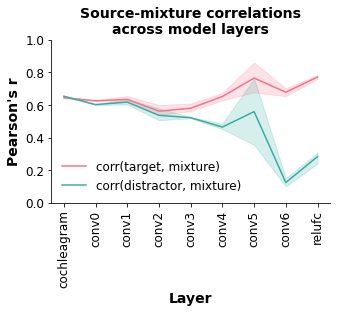

In [58]:

fontsize=14

fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(5,3)

g = sns.lineplot(data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette='husl', 
              hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],)
#               order = layer_order,
#               dodge=0.1,
#               ax=ax,
#               height=1, #ratio=2,
#               error='sem')

sns.despine()
g.set_xticklabels(layer_order, rotation=90, fontsize=fontsize-2)

g.set_yticks(np.linspace(0,1,6))
g.set_yticklabels(np.linspace(0,1,6).round(1), fontsize=fontsize-2)

g.set_ylabel("Pearson's r", fontsize=fontsize, weight='bold')
g.set_xlabel("Layer", fontsize=fontsize, weight='bold')
g.set_title("Source-mixture correlations\nacross model layers", size=fontsize, weight='bold')
sns.move_legend(g, title='',
                loc="lower left", 
                frameon=False, fontsize=fontsize-2 )


# plt.savefig(plot_out_dir / 'layer_corrs.pdf', bbox_inches='tight')
# plt.savefig(plot_out_dir / 'layer_corrs.svg', bbox_inches='tight' ,format="svg")

# plt.tight_layout()

In [49]:
plot_out_dir

PosixPath('/om2/user/imgriff/projects/cocktail_party/COSYNE_2023/plots')

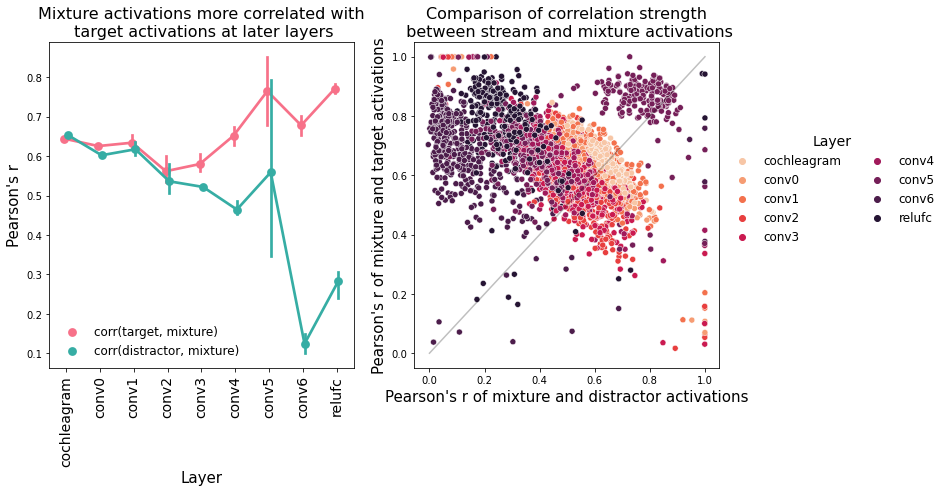

In [164]:
fig, axs = plt.subplots(1,2, figsize=(12,6))


x = y = np.linspace(0,1,100)

sns.pointplot(data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette='husl', ax=axs[0],
              hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],
              order = layer_order,
              dodge=0.1,
              error='sem')


axs[1].plot(x,y,'k-', alpha=0.25)
sns.scatterplot(data=model_df, x='bg_corrs', y='fg_corrs',
                hue='layer',hue_order=layer_order, palette='rocket_r', ax=axs[1])


axs[0].set_title("Mixture activations more correlated with\n target activations at later layers", fontsize=16)
axs[0].set_xticklabels(layer_order, rotation=90, fontsize=14);
axs[0].set_ylabel("Pearson's r", fontsize=15)
axs[0].set_xlabel("Layer", fontsize=15)
axs[0].legend(title='', loc='lower left', frameon=False,
              fontsize=12, title_fontsize=14)


axs[1].set_title("Comparison of correlation strength\n between stream and mixture activations", fontsize=16)
axs[1].set_xlabel("Pearson's r of mixture and distractor activations", fontsize=15)
axs[1].set_ylabel("Pearson's r of mixture and target activations", fontsize=15)
axs[1].legend(title='Layer', ncol=2, frameon=False,
              bbox_to_anchor=(1, 0.75), fontsize=12, title_fontsize=14)




# plt.tight_layout()

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:3775: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try pointplot
  warnings.warn(msg, UserWarning)


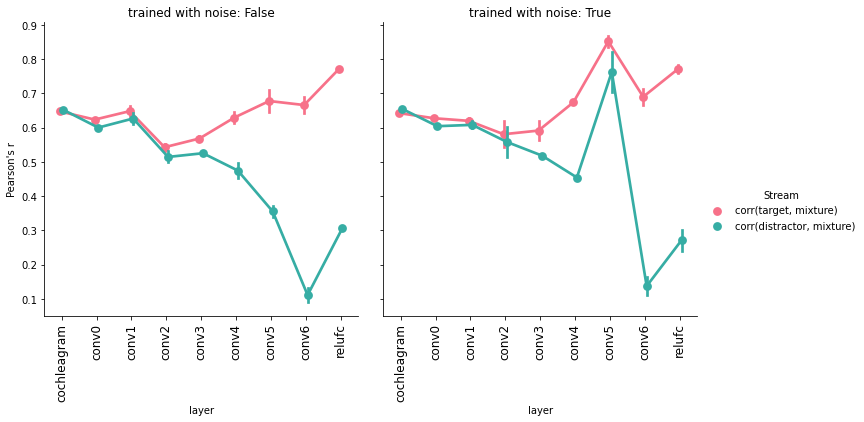

In [174]:
g = sns.catplot(kind='point', data=results, x='layer', y="Pearson's r",
              hue = 'Stream', palette='husl', ax=axs[0],
              col='with_noise',
              hue_order = ['corr(target, mixture)', 'corr(distractor, mixture)'],
              order = layer_order,
              dodge=0.1,
              error='sem')

g.set_xticklabels(rotation=90, fontsize=fontsize)
# g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_titles("trained with noise: {col_name}", size=fontsize)